In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from bleed_masking import bleed_masking

## Bleeding Masking Algorithm

In [2]:

import sys
import numpy
import matplotlib
import astropy
import photutils

print("Python:", sys.version)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("astropy:", astropy.__version__)
print("photutils:", photutils.__version__)

import notebook
print("notebook:", notebook.__version__)

Python: 3.10.9 (main, Mar  1 2023, 18:23:06) [GCC 11.2.0]
numpy: 1.26.3
matplotlib: 3.9.2
astropy: 6.1.3
photutils: 2.0.2
notebook: 7.2.2


## Generating the bleed masks for the 1084 field of KS4. 

In [ ]:
path_KMTNet_CTIO_N_img = 'data/ks4.1084.179-34.I.dith0.kmtc.20210407.022071.nn.fits'
path_KMTNet_CTIO_T_img = 'data/ks4.1084.179-34.I.dith0.kmtc.20210407.022071.tt.fits'

# Saturation threshold is set to 50000 for every single-epoch images except for T chip in CTIO, which is set to 40000
bleed_mask_CTIO_N = bleed_masking(path_KMTNet_CTIO_N_img, saturate=50000, BI_thres=500, detect_thres=0.4, CL=6, flagval=1)
bleed_mask_CTIO_T = bleed_masking(path_KMTNet_CTIO_T_img, saturate=40000, BI_thres=500, detect_thres=0.4, CL=6, flagval=1)

## Comparing the image and the generated bleed mask.


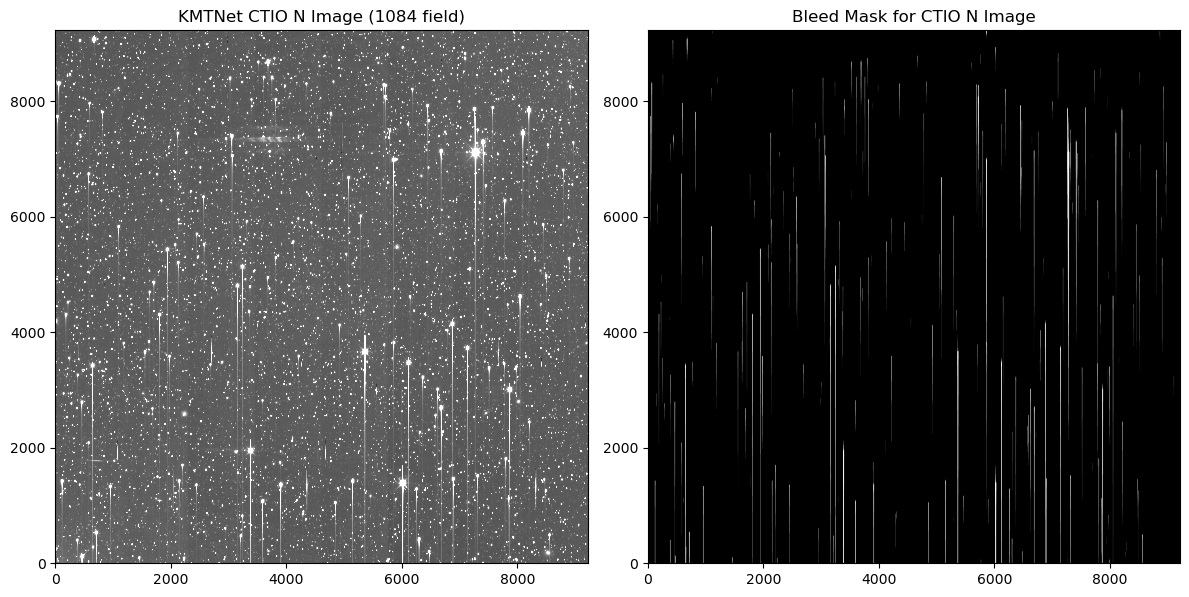

In [ ]:
# CTIO N chip

KMTNet_CTIO_N_img = fits.getdata(path_KMTNet_CTIO_N_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
vmin_N, vmax_N = ZScaleInterval().get_limits(KMTNet_CTIO_N_img)
plt.imshow(KMTNet_CTIO_N_img, cmap='gray', vmin=vmin_N, vmax=vmax_N, origin='lower')
plt.title('KMTNet CTIO N Image (1084 field)')
plt.subplot(1, 2, 2)
plt.imshow(bleed_mask_CTIO_N, cmap='gray', origin='lower')
plt.title('Bleeding Mask for CTIO N Image')
plt.tight_layout()
plt.show()

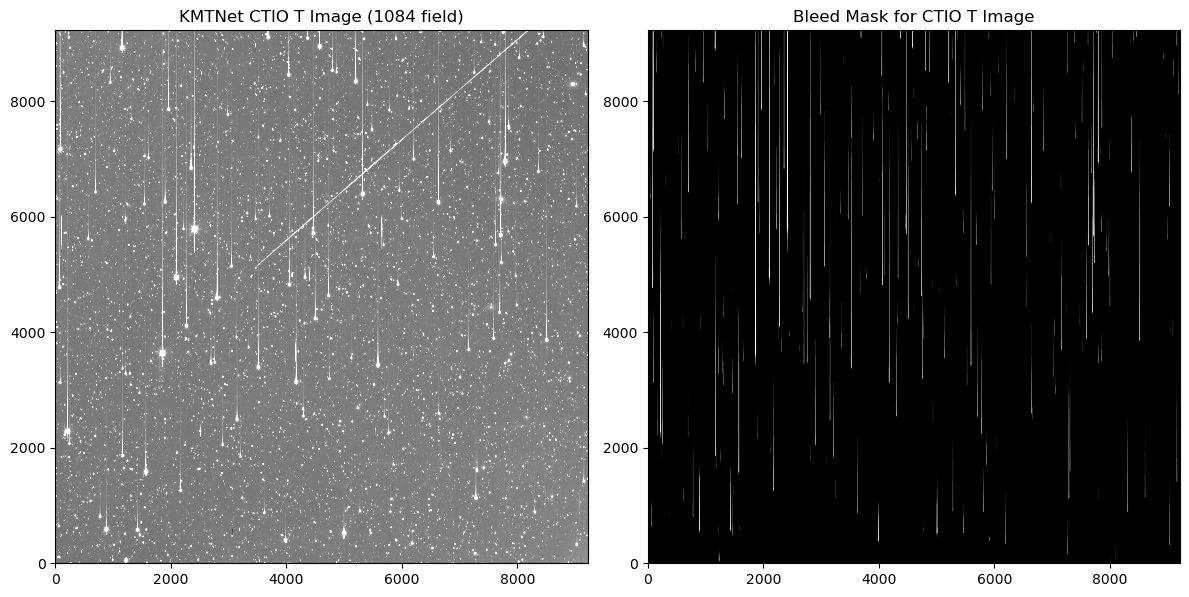

In [ ]:
# CTIO T chip

KMTNet_CTIO_T_img = fits.getdata(path_KMTNet_CTIO_T_img)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
vmin_T, vmax_T = ZScaleInterval().get_limits(KMTNet_CTIO_T_img)
plt.imshow(KMTNet_CTIO_T_img, cmap='gray', vmin=vmin_T, vmax=vmax_T, origin='lower')
plt.title('KMTNet CTIO T Image (1084 field)')
plt.subplot(1, 2, 2)
plt.imshow(bleed_mask_CTIO_T, cmap='gray', origin='lower')
plt.title('Bleeding Mask for CTIO T Image')
plt.tight_layout()
plt.show()